In [19]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# 1. Carga de base procesada de manzanas
# -------------------------------------------------------------------

FP = Path("../data/processed/manzanas_penalolen_paper.parquet")

manz = gpd.read_parquet(FP)
manz = manz.to_crs(32719)

print("Dimensión base:", manz.shape)
manz.head()

Dimensión base: (1629, 22)


,CUT,COMUNA,COD_ZONA,MANZENT,COD_MANZANA,SHAPE,n_per,n_edad_60_mas,prom_edad,prom_escolaridad18,...,pct_dif_mover,pct_analfabet,pct_terciaria,pct_camina,pct_hacinamiento,pct_allegados,pct_precar_pared,pct_precar_techo,pct_piso_tierra,pct_sin_sanit
30613,13122,PEÑALOLÉN,1,1.312201e+13,3,"MULTIPOLYGON (((354058.672 6296650.284, 353963...",134.0,53.0,48.9,14.6,...,0.082090,0.007463,0.514925,0.014925,0.000000,0.007463,0.0,0.0,0.0,0.0
30614,13122,PEÑALOLÉN,1,1.312201e+13,6,"MULTIPOLYGON (((354200.259 6296552.088, 354212...",118.0,27.0,38.6,13.3,...,0.033898,0.000000,0.355932,0.016949,0.042373,0.016949,0.0,0.0,0.0,0.0
30615,13122,PEÑALOLÉN,1,1.312201e+13,7,"MULTIPOLYGON (((353840.343 6296401.973, 353841...",9.0,4.0,50.1,11.0,...,0.000000,0.000000,0.222222,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
30616,13122,PEÑALOLÉN,1,1.312201e+13,8,"MULTIPOLYGON (((354460.616 6296396.127, 354459...",47.0,10.0,40.5,13.3,...,0.063830,0.000000,0.319149,0.106383,0.021277,0.000000,0.0,0.0,0.0,0.0
30617,13122,PEÑALOLÉN,1,1.312201e+13,9,"MULTIPOLYGON (((354064.167 6296424.865, 354062...",240.0,63.0,42.1,14.7,...,0.029167,0.004167,0.479167,0.029167,0.008333,0.008333,0.0,0.0,0.0,0.0


In [20]:
# -------------------------------------------------------------------
# 2. Variables para el índice de vulnerabilidad
# -------------------------------------------------------------------

vars_vuln = [
    "pct_60mas",
    "pct_discapacidad",
    "pct_analfabet",
    "pct_hacinamiento",
    "pct_allegados",
    "pct_camina",
]

vars_check = vars_vuln + ["pct_terciaria"]

manz[vars_check].describe().T

,count,mean,std,min,25%,50%,75%,max
pct_60mas,1629.0,0.213472,0.081925,0.0,0.163889,0.209459,0.261111,0.659091
pct_discapacidad,1629.0,0.102117,0.055122,0.0,0.060241,0.100694,0.138614,0.346154
pct_analfabet,1629.0,0.015421,0.017792,0.0,0.000000,0.011364,0.024590,0.136364
pct_hacinamiento,1629.0,0.019046,0.018990,0.0,0.000000,0.015873,0.030675,0.131579
pct_allegados,1629.0,0.015830,0.020962,0.0,0.000000,0.008671,0.023923,0.153846
pct_camina,1629.0,0.029266,0.026156,0.0,0.007353,0.026087,0.044248,0.200000
pct_terciaria,1629.0,0.247807,0.183998,0.0,0.104839,0.161290,0.411765,0.809524


In [21]:
# -------------------------------------------------------------------
# 3. Correlaciones entre variables seleccionadas
# -------------------------------------------------------------------

corr = manz[vars_check].corr()
print(corr.round(2))

                  pct_60mas  pct_discapacidad  pct_analfabet  \
pct_60mas              1.00              0.28           0.00   
pct_discapacidad       0.28              1.00           0.42   
pct_analfabet          0.00              0.42           1.00   
pct_hacinamiento      -0.10              0.32           0.27   
pct_allegados          0.04              0.29           0.29   
pct_camina             0.00              0.35           0.31   
pct_terciaria          0.06             -0.56          -0.51   

                  pct_hacinamiento  pct_allegados  pct_camina  pct_terciaria  
pct_60mas                    -0.10           0.04        0.00           0.06  
pct_discapacidad              0.32           0.29        0.35          -0.56  
pct_analfabet                 0.27           0.29        0.31          -0.51  
pct_hacinamiento              1.00           0.38        0.32          -0.56  
pct_allegados                 0.38           1.00        0.23          -0.42  
pct_camina   

In [23]:
# -------------------------------------------------------------------
# 4. Construcción del índice de vulnerabilidad
# pct_terciaria se incorpora como factor protector (signo negativo)
# -------------------------------------------------------------------

X = manz[vars_vuln].copy()
X["inv_pct_terciaria"] = -manz["pct_terciaria"]

scaler = StandardScaler()
Xz = scaler.fit_transform(X)

manz["indice_vulnerabilidad"] = Xz.mean(axis=1)

print(manz["indice_vulnerabilidad"].describe())

count    1.629000e+03
mean     3.489467e-17
std      6.189561e-01
min     -1.429252e+00
25%     -5.129105e-01
50%      1.016856e-01
75%      4.358258e-01
max      2.134070e+00
Name: indice_vulnerabilidad, dtype: float64


In [25]:
# -------------------------------------------------------------------
# 5. Clasificación ordinal de vulnerabilidad
# - quintiles: útil para mapas
# - 3 grupos: útil para simulación y cruce con EOD
# -------------------------------------------------------------------

manz["vuln_q"] = pd.qcut(
    manz["indice_vulnerabilidad"],
    q=5,
    labels=["Muy baja", "Baja", "Media", "Alta", "Muy alta"]
)

manz["vuln_group"] = pd.qcut(
    manz["indice_vulnerabilidad"],
    q=3,
    labels=["baja", "media", "alta"]
)

print(manz["vuln_group"].value_counts(normalize=False))

vuln_group
baja     543
media    543
alta     543
Name: count, dtype: int64


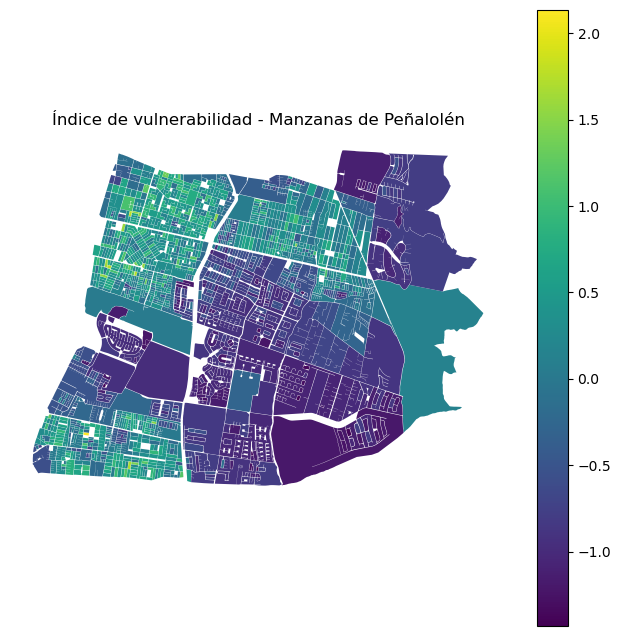

In [26]:
# -------------------------------------------------------------------
# 6. Mapas de control
# -------------------------------------------------------------------

ax = manz.plot(
    column="indice_vulnerabilidad",
    cmap="viridis",
    legend=True,
    figsize=(8, 8)
)
ax.set_axis_off()
ax.set_title("Índice de vulnerabilidad - Manzanas de Peñalolén")
plt.show()

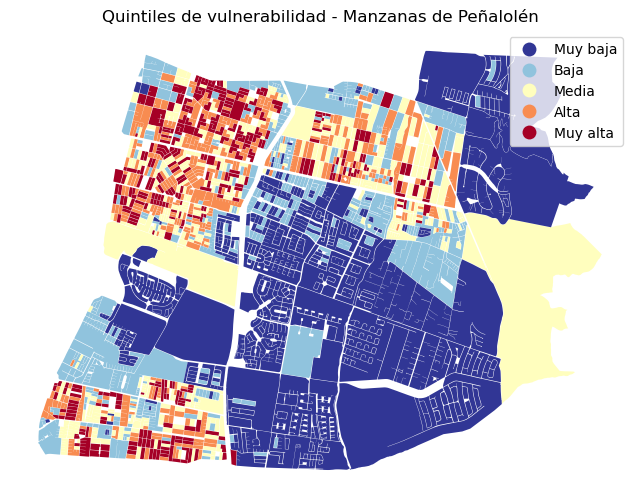

In [27]:
ax = manz.plot(
    column="vuln_q",
    cmap="RdYlBu_r",
    legend=True,
    figsize=(8, 8)
)
ax.set_axis_off()
ax.set_title("Quintiles de vulnerabilidad - Manzanas de Peñalolén")
plt.show()

In [28]:
# -------------------------------------------------------------------
# 7. Revisión de extremos
# -------------------------------------------------------------------

top_vuln = manz.sort_values("indice_vulnerabilidad", ascending=False)[
    ["MANZENT", "COD_MANZANA", "n_per", "n_edad_60_mas",
     "pct_60mas", "pct_discapacidad", "pct_analfabet",
     "pct_hacinamiento", "pct_allegados", "pct_camina",
     "pct_terciaria", "indice_vulnerabilidad", "vuln_group"]
].head(10)

low_vuln = manz.sort_values("indice_vulnerabilidad", ascending=True)[
    ["MANZENT", "COD_MANZANA", "n_per", "n_edad_60_mas",
     "pct_60mas", "pct_discapacidad", "pct_analfabet",
     "pct_hacinamiento", "pct_allegados", "pct_camina",
     "pct_terciaria", "indice_vulnerabilidad", "vuln_group"]
].head(10)

print("Manzanas más vulnerables")
display(top_vuln)

print("Manzanas menos vulnerables")
display(low_vuln)

Manzanas más vulnerables


,MANZENT,COD_MANZANA,n_per,n_edad_60_mas,pct_60mas,pct_discapacidad,pct_analfabet,pct_hacinamiento,pct_allegados,pct_camina,pct_terciaria,indice_vulnerabilidad,vuln_group
31663,1.312204e+13,14,44.0,18.0,0.409091,0.250000,0.136364,0.000000,0.000000,0.136364,0.113636,2.134070,alta
30702,1.312201e+13,24,85.0,23.0,0.270588,0.200000,0.070588,0.023529,0.129412,0.047059,0.141176,1.784540,alta
32766,1.312211e+13,15,23.0,5.0,0.217391,0.260870,0.086957,0.000000,0.086957,0.086957,0.130435,1.740855,alta
32812,1.312211e+13,20,71.0,11.0,0.154930,0.056338,0.056338,0.098592,0.126761,0.056338,0.084507,1.737394,alta
32666,1.312210e+13,18,84.0,25.0,0.297619,0.226190,0.083333,0.071429,0.035714,0.035714,0.107143,1.688105,alta
32761,1.312211e+13,7,143.0,31.0,0.216783,0.181818,0.020979,0.048951,0.153846,0.048951,0.125874,1.625199,alta
32124,1.312206e+13,42,49.0,14.0,0.285714,0.204082,0.061224,0.061224,0.000000,0.122449,0.102041,1.590030,alta
32051,1.312206e+13,6,120.0,31.0,0.258333,0.325000,0.033333,0.025000,0.108333,0.025000,0.075000,1.586248,alta
32779,1.312211e+13,28,28.0,6.0,0.214286,0.071429,0.071429,0.071429,0.035714,0.107143,0.000000,1.519379,alta
30717,1.312201e+13,23,43.0,16.0,0.372093,0.186047,0.093023,0.023256,0.000000,0.116279,0.255814,1.510490,alta


Manzanas menos vulnerables


,MANZENT,COD_MANZANA,n_per,n_edad_60_mas,pct_60mas,pct_discapacidad,pct_analfabet,pct_hacinamiento,pct_allegados,pct_camina,pct_terciaria,indice_vulnerabilidad,vuln_group
30847,1.312203e+13,24,38.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.578947,-1.429252,baja
31728,1.312205e+13,30,31.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.548387,-1.405518,baja
31555,1.312203e+13,28,30.0,1.0,0.033333,0.000000,0.0,0.0,0.0,0.0,0.600000,-1.387460,baja
31570,1.312203e+13,55,44.0,1.0,0.022727,0.000000,0.0,0.0,0.0,0.0,0.568182,-1.381248,baja
31121,1.312203e+13,75,21.0,3.0,0.142857,0.000000,0.0,0.0,0.0,0.0,0.809524,-1.359143,baja
31540,1.312203e+13,4,44.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.477273,-1.350287,baja
31088,1.312203e+13,50,22.0,1.0,0.045455,0.000000,0.0,0.0,0.0,0.0,0.545455,-1.323954,baja
31074,1.312203e+13,34,38.0,2.0,0.052632,0.000000,0.0,0.0,0.0,0.0,0.526316,-1.296571,baja
31246,1.312203e+13,91,40.0,0.0,0.000000,0.025000,0.0,0.0,0.0,0.0,0.475000,-1.283711,baja
30845,1.312203e+13,19,79.0,3.0,0.037975,0.012658,0.0,0.0,0.0,0.0,0.518987,-1.283630,baja


In [31]:
# -------------------------------------------------------------------
# 8. Geometría operativa para simulación
# Usamos representative_point para asegurar que el punto quede dentro
# de la manzana (mejor que centroid en polígonos raros)
# -------------------------------------------------------------------

manz["rep_point"] = manz.geometry.representative_point()
manz["x_rep"] = manz["rep_point"].x
manz["y_rep"] = manz["rep_point"].y


# Se cambia el nombre de la columna de geometría
manz["geometry"] = manz["SHAPE"]

In [32]:
# -------------------------------------------------------------------
# 9. Tabla mínima para simulación
# -------------------------------------------------------------------

cols_sim = [
    "MANZENT",
    "COD_MANZANA",
    "n_per",
    "n_edad_60_mas",
    "indice_vulnerabilidad",
    "vuln_group",
    "x_rep",
    "y_rep",
    "geometry"
]

manz_sim = manz[cols_sim].copy()

print("Dimensión tabla simulación:", manz_sim.shape)
manz_sim.head()

Dimensión tabla simulación: (1629, 9)


,MANZENT,COD_MANZANA,n_per,n_edad_60_mas,indice_vulnerabilidad,vuln_group,x_rep,y_rep,geometry
30613,1.312201e+13,3,134.0,53.0,-0.129681,media,354095.616422,6.296589e+06,"MULTIPOLYGON (((354058.672 6296650.284, 353963..."
30614,1.312201e+13,6,118.0,27.0,-0.176136,media,354242.843965,6.296505e+06,"MULTIPOLYGON (((354200.259 6296552.088, 354212..."
30615,1.312201e+13,7,9.0,4.0,-0.376962,baja,353831.281093,6.296461e+06,"MULTIPOLYGON (((353840.343 6296401.973, 353841..."
30616,1.312201e+13,8,47.0,10.0,0.215923,media,354400.351163,6.296437e+06,"MULTIPOLYGON (((354460.616 6296396.127, 354459..."
30617,1.312201e+13,9,240.0,63.0,-0.397915,baja,353977.039554,6.296382e+06,"MULTIPOLYGON (((354064.167 6296424.865, 354062..."


In [41]:
# -------------------------------------------------------------------
# 10. Exportar tabla final del censo para simulación
# -------------------------------------------------------------------
manz_sim["vuln_group"] = manz_sim["vuln_group"].astype(str)

manz_sim_export = manz_sim.copy()

# asegurar geometría activa
manz_sim_export = gpd.GeoDataFrame(
    manz_sim_export,
    geometry="geometry",
    crs=manz_sim["geometry"].crs
)

OUT_DIR = Path("../data/processed/censo")
OUT_DIR.mkdir(parents=True, exist_ok=True)

manz_sim_export.to_parquet(OUT_DIR / "manzanas_penalolen_sim.parquet")

manz_sim_export.to_file(
    OUT_DIR / "manzanas_penalolen_sim.gpkg",
    layer="manzanas_sim",
    driver="GPKG"
)

print("Exportado en:", OUT_DIR.resolve())

Exportado en: C:\Users\mbell\Desktop\UNIVERSIDAD\DOCTORADO\TESIS\REPOSITORIOS\simulador-am-tesis\data\processed\censo
